<a href="https://colab.research.google.com/github/isabelcordova-hash/Mineria-de-Datos-/blob/main/LAB11/LAB_S11_MDD_ICORDOVA_2026_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LABORATORIO N. 11

## Clustering: Métodos No Supervisados

**Curso:** Minería de Datos  
**Semana:** 11  
**Caso 11:** Segmentación de clientes y análisis del dataset Credit Card Fraud Detection  
**Dataset:** Credit Card Fraud Detection - Kaggle (`mlg-ulb/creditcardfraud`)  
**Docente:** Pilar Rocío Sayán Mejía



## Objetivo del laboratorio

Aplicar métodos no supervisados para segmentar transacciones financieras. El laboratorio trabaja K-Means, variantes de K-Means, método del codo, inercia, silhouette score, reducción visual con PCA, clustering jerárquico con dendrograma, clustering aglomerativo y una comparación pedagógica con Fuzzy C-Means y Canopy Clustering.

El énfasis está en interpretar los clusters como perfiles de negocio.

## Caso de negocio

Una entidad financiera analiza miles de transacciones con tarjeta. Aunque el dataset incluye una etiqueta de fraude (`Class`), el objetivo principal de esta sesión no es entrenar un clasificador supervisado. El reto es descubrir grupos naturales de transacciones y describirlos como perfiles de comportamiento.

El equipo de analistas debe responder:

- Qué grupos de transacciones aparecen en los datos?
- Qué características tiene cada grupo?
- Qué cluster debería revisar primero el área de monitoreo?
- Qué tan estable parece la segmentación al comparar métodos?

## Secuencia de trabajo

1. Carga y exploración del dataset.
2. Preparación de variables para clustering.
3. Escalado de datos.
4. K-Means e interpretación inicial.
5. Método del codo e inercia.
6. Silhouette score.
7. Perfilamiento de clusters.
8. Visualización con PCA.
9. Clustering jerárquico y dendrograma.
10. Aglomerativo y divisivo.
11. Variantes: MiniBatch K-Means, Fuzzy C-Means y Canopy.
12. Conclusiones de negocio.

## Conceptos clave

- **Clustering:** técnica no supervisada que agrupa observaciones similares.
- **Distancia:** criterio para medir parecido entre observaciones.
- **Escalado:** paso necesario antes de calcular distancias.
- **K-Means:** algoritmo basado en centroides.
- **Inercia:** mide qué tan compactos son los clusters.
- **Silhouette score:** mide cohesión interna y separación entre clusters.
- **Jerárquico aglomerativo:** empieza con observaciones separadas y las va uniendo.
- **Divisivo:** empieza con un grupo grande y lo va dividiendo.
- **Fuzzy C-Means:** permite pertenencia parcial a más de un cluster.
- **Canopy Clustering:** crea pregrupos rápidos para explorar grandes volúmenes de datos.

## Actividad 1: revisión conceptual

Antes de programar, responda: por qué clustering no necesita una variable objetivo?, por qué las distancias pueden cambiar si no escalamos?, y por qué un cluster debe interpretarse con contexto de negocio?

### Código 1: importar librerías

Este bloque carga herramientas para datos, gráficos, K-Means, PCA y clustering jerárquico.

In [ ]:
import os
import glob
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 40)
SEED = 42

**Pregunta 1:** Qué librerías se usarán para clustering, visualización y reducción de dimensionalidad?

* **Clustering:** `sklearn.cluster` para implementar KMeans, MiniBatchKMeans y AgglomerativeClustering.
* **Visualización:** `matplotlib.pyplot` y `seaborn` para la generación de gráficos de dispersión, líneas y dendrogramas.
* **Reducción de dimensionalidad:** `sklearn.decomposition.PCA` para proyectar los datos en 2 componentes principales y facilitar su visualización.
* **Análisis jerárquico:** `scipy.cluster.hierarchy` para el cálculo y trazado del dendrograma.



### Código 2: cargar la base de datos

El laboratorio usa la base **Credit Card Fraud Detection** de Kaggle. Si KaggleHub no está disponible, se intenta leer una copia pública del mismo archivo.

In [ ]:
url_publica = 'https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv'
fuente_datos = ''

try:
    import kagglehub
    ruta = kagglehub.dataset_download('mlg-ulb/creditcardfraud')
    archivo_csv = glob.glob(os.path.join(ruta, '*.csv'))[0]
    df = pd.read_csv(archivo_csv)
    fuente_datos = 'Kaggle: mlg-ulb/creditcardfraud'
except Exception:
    try:
        df = pd.read_csv(url_publica)
        fuente_datos = 'Copia pública del dataset de Kaggle'
    except Exception:
        import requests
        respuesta = requests.get(url_publica, timeout=90, verify=False)
        respuesta.raise_for_status()
        df = pd.read_csv(io.StringIO(respuesta.text))
        fuente_datos = 'Copia pública del dataset leída con requests'

print('Fuente:', fuente_datos)
print('Filas y columnas:', df.shape)
display(df.head())

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Fuente: Kaggle: mlg-ulb/creditcardfraud
Filas y columnas: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Pregunta 2:** Cuántas filas y columnas tiene la base? Qué representa una fila en este caso?


El conjunto de datos contiene 284,807 filas y 31 columnas. Cada fila representa una transacción individual con tarjeta de crédito, compuesta por los siguientes elementos:

* **Time:** Variable temporal que indica los segundos transcurridos desde la primera transacción.
* **V1 a V28:** Características numéricas anonimizadas mediante PCA para proteger la privacidad.
* **Amount:** Monto monetario de la transacción.
* **Class:** Etiqueta objetivo que indica el estado de la transacción (0 = legítima, 1 = fraude).

### Código 3: revisar estructura y clase de referencia

La columna `Class` se revisa para entender el contexto, pero no se usará para formar clusters.

In [ ]:
display(df.info())

tabla_clases = df['Class'].value_counts().rename_axis('clase').reset_index(name='cantidad')
tabla_clases['porcentaje'] = (tabla_clases['cantidad'] / len(df) * 100).round(4)
display(tabla_clases)

display(df[['Time', 'Amount', 'Class']].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

,clase,cantidad,porcentaje
0,0,284315,99.8273
1,1,492,0.1727


,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


**Pregunta 3:** Qué indica el porcentaje de fraudes sobre el tipo de problema que analiza la entidad financiera?

El porcentaje de fraudes del 0.1727% indica que la entidad financiera enfrenta un problema de clases altamente desbalanceadas o problema de eventos raros. Esto significa que las transacciones fraudulentas son muy poco frecuentes en comparación con las transacciones legítimas. Este desbalance es un desafío común en la detección de fraudes y requiere técnicas especializadas para asegurar que los modelos no supervisados (y futuros modelos supervisados) puedan identificar correctamente la minoría fraudulenta sin generar demasiados falsos positivos.

### Código 4: preparar variables para clustering

Se usan las variables anonimizadas `V1` a `V28` y el monto `Amount`. La etiqueta `Class` se separa y queda solo como referencia posterior.

In [ ]:
columnas_cluster = [f'V{i}' for i in range(1, 29)] + ['Amount']

n_muestra = min(8000, len(df))
df_muestra = df.sample(n=n_muestra, random_state=SEED)

X_cluster = df_muestra[columnas_cluster].copy()
clase_referencia = df_muestra['Class'].astype(int).copy()

print('Muestra para clustering:', X_cluster.shape)
print('Fraudes en la muestra, solo para interpretación posterior:', int(clase_referencia.sum()))
display(X_cluster.head())

Muestra para clustering: (8000, 29)
Fraudes en la muestra, solo para interpretación posterior: 12


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
43428,-16.526507,8.584972,-18.649853,9.505594,-13.793819,-2.832404,-16.701694,7.517344,-8.507059,-14.110184,5.299236,-10.834006,1.671120,-9.373859,0.360806,-9.899247,-19.236292,-8.398552,3.101735,-1.514923,1.190739,-1.127670,-2.358579,0.673461,-1.413700,-0.462762,-2.018575,-1.042804,364.19
49906,0.339812,-2.743745,-0.134070,-1.385729,-1.451413,1.015887,-0.524379,0.224060,0.899746,-0.565012,-0.087670,0.979427,0.076883,-0.217884,-0.136830,-2.142892,0.126956,1.752662,0.432546,0.506044,-0.213436,-0.942525,-0.526819,-1.156992,0.311211,-0.746647,0.040996,0.102038,520.12
29474,1.399590,-0.590701,0.168619,-1.029950,-0.539806,0.040444,-0.712567,0.002299,-0.971747,0.756801,0.543827,0.112453,1.075384,-0.245772,0.180483,1.769860,-0.533172,-0.533300,1.192245,0.212877,0.102398,0.168269,-0.166639,-0.810250,0.505083,-0.232340,0.011409,0.004634,31.00
276481,-0.432071,1.647895,-1.669361,-0.349504,0.785785,-0.630647,0.276990,0.586025,-0.484715,-1.376648,-1.328335,0.223621,1.132627,-0.550875,0.616568,0.497974,0.502195,0.981343,0.101264,-0.244633,0.358932,0.873663,-0.178642,-0.017171,-0.207392,-0.157756,-0.237386,0.001934,1.50
278846,2.014160,-0.137394,-1.015839,0.327269,-0.182179,-0.956571,0.043241,-0.160746,0.363241,0.259452,0.942162,0.850038,-0.616166,0.592634,-0.603845,0.091077,-0.471867,-0.333816,0.404711,-0.255293,-0.238644,-0.616400,0.347045,0.061561,-0.360196,0.174730,-0.078043,-0.070571,0.89


**Pregunta 4:** Por qué `Class` no debe entrar como variable para entrenar K-Means?

La variable Class no debe entrar como variable para entrenar K-Means porque K-Means es un algoritmo de aprendizaje no supervisado. Su objetivo es descubrir patrones y agrupar datos basándose únicamente en sus características intrínsecas, sin usar ninguna etiqueta preexistente. Incluir Class convertiría el problema en uno supervisado, lo que alteraría el propósito del clustering no supervisado.

### Código 5: escalado de datos

K-Means usa distancias. Por eso se estandarizan las variables para que todas contribuyan de manera comparable.

In [ ]:
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X_cluster)

df_escalado = pd.DataFrame(X_escalado, columns=columnas_cluster)
display(df_escalado[['V1', 'V2', 'Amount']].describe().round(3))

,V1,V2,Amount
count,8000.000,8000.000,8000.000
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-16.385,-26.198,-0.369
25%,-0.440,-0.325,-0.347
50%,0.012,0.042,-0.278
75%,0.652,0.439,-0.044
max,1.170,7.956,21.820


**Pregunta 5:** Qué observa en la media y desviación estándar después del escalado?

Después del escalado con StandardScaler, se observa que la media de las variables es muy cercana a 0, y la desviación estándar es muy cercana a 1. Este es el resultado esperado de la estandarización, donde cada característica se transforma para tener una media de 0 y una varianza de 1, lo que asegura que todas las variables contribuyan de manera equitativa a los cálculos de distancia en algoritmos como K-Means.


### Código 6: K-Means inicial con k = 3

Se inicia con tres clusters para observar una segmentación básica.

In [ ]:
kmeans_3 = KMeans(n_clusters=3, n_init=10, random_state=SEED)
clusters_3 = kmeans_3.fit_predict(X_escalado)

df_k3 = df_muestra.copy()
df_k3['cluster_k3'] = clusters_3

display(df_k3[['Amount', 'Class', 'cluster_k3']].head())
display(df_k3['cluster_k3'].value_counts().sort_index().rename_axis('cluster').reset_index(name='transacciones'))

,Amount,Class,cluster_k3
43428,364.19,1,0
49906,520.12,0,1
29474,31.00,0,2
276481,1.50,0,1
278846,0.89,0,0


,cluster,transacciones
0,0,3657
1,1,3129
2,2,1214


**Pregunta 6:** Qué significa que una transacción pertenezca al cluster 0, 1 o 2?

Cuando una transacción pertenece a un cluster (0, 1, 2, o cualquier otro), significa que, en base a las variables utilizadas para el clustering (V1-V28 y Amount, escaladas), esa transacción es más similar a las otras transacciones dentro de ese mismo cluster que a las transacciones de cualquier otro cluster. En otras palabras, comparte características comunes en términos de los patrones de las variables anonimizadas y el monto, lo que sugiere un comportamiento similar dentro de ese grupo. Los clusters son grupos de transacciones que el algoritmo K-Means ha encontrado que tienen características similares.


### Código 7: método del codo e inercia

La inercia mide compactación. Se comparan k = 3, 4 y 5, tal como se plantea para la semana.

,k,inercia
0,3,217686.98
1,4,209602.99
2,5,204056.69


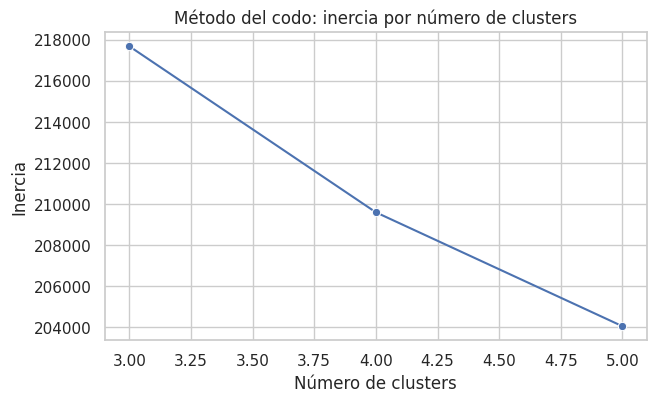

In [ ]:
valores_k = [3, 4, 5]
inercias = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    modelo.fit(X_escalado)
    inercias.append(modelo.inertia_)

df_codo = pd.DataFrame({'k': valores_k, 'inercia': inercias})
display(df_codo.round(2))

plt.figure(figsize=(7, 4))
sns.lineplot(data=df_codo, x='k', y='inercia', marker='o')
plt.title('Método del codo: inercia por número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.show()

**Pregunta 7:** Qué valor de k parece razonable según la inercia? La mejora entre k aumenta o disminuye?

Observando los valores de inercia, la mayor reducción ocurre al pasar de k=3 a k=4 (aproximadamente 8084 unidades de inercia), y luego la reducción disminuye al pasar de k=4 a k=5 (aproximadamente 5546 unidades). Si bien no hay un 'codo' extremadamente pronunciado con solo tres puntos, se observa que la mejora en la inercia disminuye a medida que se aumenta el número de clusters. Un valor de k=4 podría considerarse razonable, ya que ofrece una buena reducción inicial, aunque k=5 todavía proporciona una reducción adicional.

### Código 8: silhouette score

El silhouette score evalúa si los clusters son compactos y están separados.

,k,silhouette_score
0,3,0.0567
1,4,0.0457
2,5,0.0627


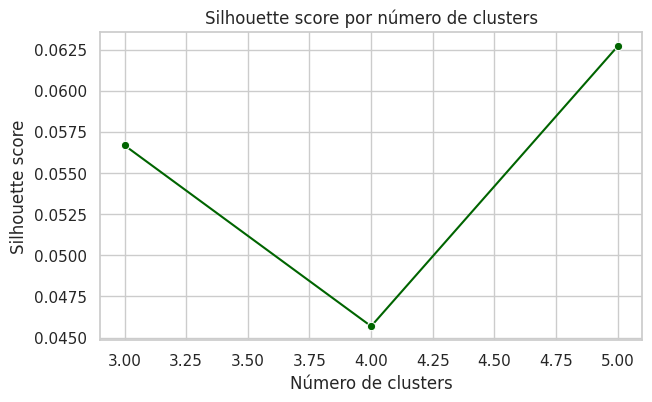

In [ ]:
siluetas = []

for k in valores_k:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    clusters = modelo.fit_predict(X_escalado)
    siluetas.append(silhouette_score(X_escalado, clusters))

df_silueta = pd.DataFrame({'k': valores_k, 'silhouette_score': siluetas})
display(df_silueta.round(4))

plt.figure(figsize=(7, 4))
sns.lineplot(data=df_silueta, x='k', y='silhouette_score', marker='o', color='darkgreen')
plt.title('Silhouette score por número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Silhouette score')
plt.show()

**Pregunta 8:** Qué k obtiene mejor silhouette score? Coincide con su lectura del método del codo?

Según el df_silueta, el valor de k=5 obtiene el mejor silhouette score con 0.0627. Esto no coincide completamente con la lectura del método del codo, donde k=4 fue identificado como un valor razonable por su buena reducción inicial, aunque k=5 también mostró una reducción adicional en la inercia. El silhouette score sugiere que, considerando tanto la cohesión dentro del cluster como la separación entre clusters, k=5 es una mejor opción.


### Código 9: entrenar K-Means final y perfilar clusters

Se elige el k con mayor silhouette score y se interpreta cada grupo con variables de negocio.

In [ ]:
mejor_k = int(df_silueta.sort_values('silhouette_score', ascending=False).iloc[0]['k'])

kmeans_final = KMeans(n_clusters=mejor_k, n_init=10, random_state=SEED)
clusters_finales = kmeans_final.fit_predict(X_escalado)

df_resultado = df_muestra.copy()
df_resultado['cluster'] = clusters_finales

perfil_clusters = df_resultado.groupby('cluster').agg(
    transacciones=('Class', 'size'),
    monto_promedio=('Amount', 'mean'),
    monto_mediano=('Amount', 'median'),
    fraude_observado=('Class', 'sum'),
    tasa_fraude=('Class', 'mean')
).reset_index()

perfil_clusters['monto_promedio'] = perfil_clusters['monto_promedio'].round(2)
perfil_clusters['monto_mediano'] = perfil_clusters['monto_mediano'].round(2)
perfil_clusters['tasa_fraude_%'] = (perfil_clusters['tasa_fraude'] * 100).round(3)
perfil_clusters = perfil_clusters.drop(columns='tasa_fraude')

print('k seleccionado:', mejor_k)
display(perfil_clusters.sort_values('tasa_fraude_%', ascending=False))

k seleccionado: 5


,cluster,transacciones,monto_promedio,monto_mediano,fraude_observado,tasa_fraude_%
3,3,130,1448.30,1199.50,4,3.077
0,0,789,44.63,13.58,2,0.253
4,4,2930,67.65,22.00,5,0.171
1,1,2977,56.48,14.00,1,0.034
2,2,1174,92.06,40.00,0,0.000


**Pregunta 9:** Qué cluster parece más importante para monitoreo financiero? Justifique con monto, cantidad o tasa de fraude observada.

El Cluster 3 parece ser el más importante para el monitoreo financiero. Aunque tiene un número menor de transacciones (130), presenta el monto promedio más alto (1448.30) y, crucialmente, la tasa de fraude observada más elevada (3.077%). Esto indica que las transacciones en este cluster, si son fraudulentas, representan un impacto económico mucho mayor para la entidad financiera. Los otros clusters tienen tasas de fraude significativamente más bajas (0.253%, 0.034%, 0.171%) o montos promedio mucho menores.

### Código 10: visualización con PCA

PCA reduce la información a dos componentes para graficar los clusters. Es una visualización, no una prueba definitiva.

Varianza explicada por PC1 y PC2: [0.064 0.052]


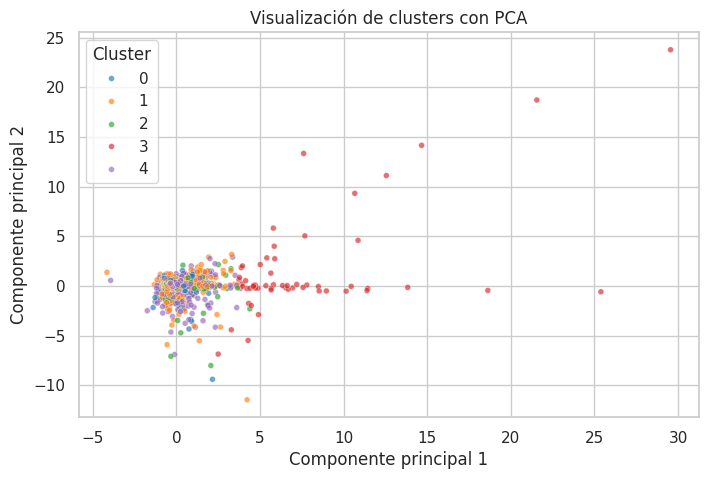

In [ ]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_escalado)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = clusters_finales
df_pca['Class'] = clase_referencia.values

print('Varianza explicada por PC1 y PC2:', np.round(pca.explained_variance_ratio_, 4))

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_pca.sample(min(3000, len(df_pca)), random_state=SEED),
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='tab10',
    alpha=0.65,
    s=18
)
plt.title('Visualización de clusters con PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend(title='Cluster')
plt.show()

**Pregunta 10:** Qué observa en el gráfico PCA? Qué limitación tiene representar muchas variables en dos componentes?

En el gráfico PCA se observa una superposición considerable entre los clusters, lo que hace difícil discernir límites claros entre ellos. Esto se debe en gran medida a la limitación inherente de representar un espacio de alta dimensionalidad (29 variables) en solo dos componentes principales. La varianza explicada por PC1 y PC2 es baja (6.4% y 5.2% respectivamente), lo que significa que estos dos componentes retienen una fracción muy pequeña de la información total presente en las 29 variables originales. Por lo tanto, lo que vemos en 2D es una proyección muy simplificada y no refleja completamente la separación o estructura real de los clusters en el espacio original de 29 dimensiones. Clusters que parecen superpuestos en 2D podrían estar bien separados en dimensiones superiores.



### Código 11: dendrograma jerárquico

El dendrograma muestra el proceso de unión de observaciones o grupos similares. Se usa una muestra pequeña para que el gráfico sea legible.

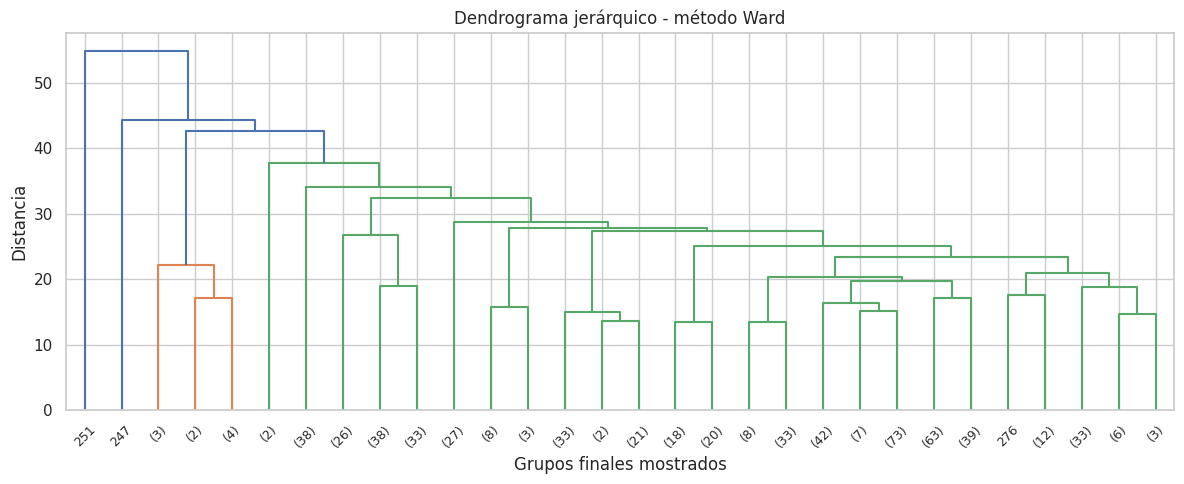

In [ ]:
n_dendrograma = min(600, X_escalado.shape[0])
indices = np.random.default_rng(SEED).choice(X_escalado.shape[0], size=n_dendrograma, replace=False)
X_dendrograma = X_escalado[indices]

enlaces = linkage(X_dendrograma, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(enlaces, truncate_mode='lastp', p=30, leaf_rotation=45, leaf_font_size=9)
plt.title('Dendrograma jerárquico - método Ward')
plt.xlabel('Grupos finales mostrados')
plt.ylabel('Distancia')
plt.tight_layout()
plt.show()

**Pregunta 11:** Qué representa la altura de las uniones en el dendrograma?

En el dendrograma, la altura de cada unión (línea horizontal) representa la distancia o disimilitud entre los dos clusters o puntos que se están uniendo. Una altura mayor indica que los clusters que se fusionan en ese punto están más separados (son menos similares) que aquellos que se fusionan a una altura menor. Es una medida de cuán 'distintos' son los grupos antes de ser combinados.



### Código 12: clustering aglomerativo

El método aglomerativo empieza con observaciones separadas y las va uniendo hasta formar el número de clusters definido.

In [ ]:
n_aglomerativo = min(2500, X_escalado.shape[0])
X_aglomerativo = X_escalado[:n_aglomerativo]
clase_aglomerativo = clase_referencia.iloc[:n_aglomerativo].values

aglomerativo = AgglomerativeClustering(n_clusters=mejor_k, linkage='ward')
clusters_aglomerativos = aglomerativo.fit_predict(X_aglomerativo)

df_aglomerativo = pd.DataFrame({
    'cluster_aglomerativo': clusters_aglomerativos,
    'Class': clase_aglomerativo,
    'Amount': df_muestra.iloc[:n_aglomerativo]['Amount'].values
})

perfil_aglomerativo = df_aglomerativo.groupby('cluster_aglomerativo').agg(
    transacciones=('Class', 'size'),
    monto_promedio=('Amount', 'mean'),
    fraude_observado=('Class', 'sum')
).reset_index()

perfil_aglomerativo['monto_promedio'] = perfil_aglomerativo['monto_promedio'].round(2)
display(perfil_aglomerativo)

,cluster_aglomerativo,transacciones,monto_promedio,fraude_observado
0,0,2401,56.51,1
1,1,95,861.23,1
2,2,1,1210.00,0
3,3,1,3502.11,0
4,4,2,1.74,0


**Pregunta 12:** En qué se diferencia el enfoque aglomerativo del enfoque K-Means?


* K-Means (Particional): Este método busca dividir el conjunto de datos en un número predefinido de clusters (k). Parte de centroides iniciales aleatorios y asigna cada punto al cluster cuyo centroide está más cerca. Luego, recalcula los centroides basándose en los puntos asignados y repite el proceso hasta que los centroides no cambian significativamente. El número de clusters k debe ser especificado de antemano.

* Aglomerativo (Jerárquico): Este método es 'bottom-up'. Comienza tratando cada punto de datos como un cluster individual. Luego, en cada paso, fusiona los dos clusters más cercanos hasta que todos los puntos están en un solo cluster grande o hasta que se alcanza un criterio de terminación (como un número deseado de clusters o una distancia máxima). El resultado es un dendrograma que muestra la jerarquía de las fusiones. No requiere un k inicial, aunque se puede cortar el dendrograma para obtener un número específico de clusters. La elección de la métrica de distancia y el método de enlace (linkage) son cruciales aquí.


### Código 13: aproximación divisiva sencilla

El enfoque divisivo empieza con un grupo grande y lo divide. Aquí se muestra una aproximación pedagógica usando K-Means para partir primero en dos y luego dividir el grupo más grande.

In [ ]:
X_divisivo = X_escalado[:2500]

division_1 = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X_divisivo)
conteo_division_1 = pd.Series(division_1).value_counts()
grupo_mayor = int(conteo_division_1.idxmax())

indices_grupo_mayor = np.where(division_1 == grupo_mayor)[0]
subdivision = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X_divisivo[indices_grupo_mayor])

clusters_divisivos = division_1.copy()
clusters_divisivos[indices_grupo_mayor[subdivision == 0]] = 2
clusters_divisivos[indices_grupo_mayor[subdivision == 1]] = 3
clusters_divisivos = pd.Series(clusters_divisivos).replace({0: 0, 1: 1, 2: 2, 3: 3})

display(clusters_divisivos.value_counts().sort_index().rename_axis('cluster_divisivo').reset_index(name='transacciones'))

,cluster_divisivo,transacciones
0,1,45
1,2,2453
2,3,2


**Pregunta 13:** Qué diferencia conceptual hay entre dividir un grupo grande y unir grupos pequeños?


La diferencia conceptual clave entre dividir un grupo grande (divisivo) y unir grupos pequeños (aglomerativo) radica en su dirección y metodología:

* Enfoque Divisivo (Top-Down): Este método comienza con todas las observaciones en un solo cluster grande. Luego, divide iterativamente el cluster más grande en clusters más pequeños, basándose en la disimilitud entre subgrupos. Este proceso continúa hasta que cada observación forma su propio cluster individual o hasta que se cumple un criterio de detención. Es análogo a romper un bloque de LEGO en piezas más pequeñas.

* Enfoque Aglomerativo (Bottom-Up): Este método comienza en el extremo opuesto, tratando cada observación individual como su propio cluster. Luego, en cada paso, fusiona los dos clusters más cercanos (más similares) en un solo cluster. Este proceso se repite hasta que todas las observaciones se agrupan en un único cluster grande o hasta que se alcanza un número deseado de clusters. Es como construir un modelo de LEGO pieza por pieza.

### Código 14: variante MiniBatch K-Means

MiniBatch K-Means es una variante de K-Means útil en datasets grandes porque actualiza centroides con lotes de datos.

In [ ]:
minibatch = MiniBatchKMeans(n_clusters=mejor_k, random_state=SEED, batch_size=512, n_init=10)
clusters_minibatch = minibatch.fit_predict(X_escalado)

comparacion_variantes = pd.DataFrame({
    'método': ['K-Means', 'MiniBatch K-Means'],
    'clusters': [len(np.unique(clusters_finales)), len(np.unique(clusters_minibatch))],
    'inercia': [kmeans_final.inertia_, minibatch.inertia_]
})

display(comparacion_variantes.round(2))

,método,clusters,inercia
0,K-Means,5,204056.69
1,MiniBatch K-Means,5,209642.41


**Pregunta 14:** Por qué MiniBatch K-Means puede ser más conveniente cuando hay muchos datos?

MiniBatch K-Means actualiza los centroides utilizando pequeños lotes aleatorios en cada iteración, en lugar de procesar todo el dataset, esto reduce drásticamente el costo computacional y el consumo de memoria, acelerando el entrenamiento sin sacrificar significativamente la calidad de la segmentación, es ideal para volúmenes masivos o entornos con recursos limitados.

### Código 15: pertenencia flexible como idea de Fuzzy C-Means

Fuzzy C-Means permite que una observación pertenezca parcialmente a varios clusters. Para no instalar librerías adicionales, se muestra una aproximación conceptual usando distancia a centroides de K-Means.

In [ ]:
distancias = kmeans_final.transform(X_escalado[:10])
distancias_seguras = np.where(distancias == 0, 1e-6, distancias)
pertenencias = (1 / distancias_seguras) / (1 / distancias_seguras).sum(axis=1, keepdims=True)

columnas_pertenencia = [f'pertenencia_cluster_{i}' for i in range(pertenencias.shape[1])]
df_pertenencia = pd.DataFrame(pertenencias, columns=columnas_pertenencia)
display(df_pertenencia.round(3))

,pertenencia_cluster_0,pertenencia_cluster_1,pertenencia_cluster_2,pertenencia_cluster_3,pertenencia_cluster_4
0,0.199,0.200,0.200,0.201,0.200
1,0.200,0.213,0.199,0.161,0.227
2,0.184,0.213,0.294,0.097,0.212
3,0.283,0.209,0.191,0.093,0.225
4,0.185,0.302,0.191,0.085,0.237
5,0.206,0.220,0.207,0.136,0.231
6,0.181,0.310,0.189,0.083,0.236
7,0.246,0.230,0.200,0.113,0.211
8,0.210,0.237,0.204,0.110,0.238
9,0.202,0.206,0.219,0.166,0.207


**Pregunta 15:** Qué significa que una transacción tenga pertenencias parecidas en dos clusters?

Cuando una transacción tiene pertenencias parecidas en dos clusters, significa que comparte características significativas con ambos grupos de transacciones. Es decir, esa transacción es ambigua y no encaja de manera nítida en un solo perfil. Esto puede indicar un comportamiento híbrido o de transición. Por ejemplo, podría ser una transacción que tiene elementos típicos de un cluster de "compras regulares de bajo monto" y, al mismo tiempo, ciertos atributos que la acercan a un cluster de "transacciones inusuales de monto moderado", lo que la hace un caso de interés para una revisión más detallada, ya que no se adecúa perfectamente a una categoría definida.





### Código 16: Canopy Clustering como preagrupamiento conceptual

Canopy Clustering se usa como idea de preagrupamiento rápido. En el laboratorio se resume su uso para no introducir dependencias adicionales.

In [ ]:
comparacion_metodos = pd.DataFrame({
    'método': ['K-Means', 'Jerárquico aglomerativo', 'Divisivo', 'Fuzzy C-Means', 'Canopy Clustering'],
    'idea_principal': [
        'Asigna cada observación al centroide más cercano.',
        'Une observaciones o grupos de forma progresiva.',
        'Divide un grupo grande en grupos más pequeños.',
        'Permite pertenencia parcial a más de un cluster.',
        'Crea pregrupos rápidos antes de aplicar otro algoritmo.'
    ],
    'uso_empresarial': [
        'Segmentación clara y fácil de explicar.',
        'Explorar jerarquías de grupos.',
        'Separar grupos grandes cuando se busca detalle.',
        'Clientes o transacciones con comportamiento mixto.',
        'Exploración inicial en bases grandes.'
    ]
})

display(comparacion_metodos)

,método,idea_principal,uso_empresarial
0,K-Means,Asigna cada observación al centroide más cercano.,Segmentación clara y fácil de explicar.
1,Jerárquico aglomerativo,Une observaciones o grupos de forma progresiva.,Explorar jerarquías de grupos.
2,Divisivo,Divide un grupo grande en grupos más pequeños.,Separar grupos grandes cuando se busca detalle.
3,Fuzzy C-Means,Permite pertenencia parcial a más de un cluster.,Clientes o transacciones con comportamiento mi...
4,Canopy Clustering,Crea pregrupos rápidos antes de aplicar otro a...,Exploración inicial en bases grandes.


**Pregunta 16:** Cuándo usaría Canopy como paso previo en un proyecto real?

Usaría Canopy Clustering como paso previo en un proyecto real cuando se trabaja con grandes volúmenes de datos y el objetivo es realizar una exploración inicial rápida o preprocesamiento antes de aplicar un algoritmo de clustering más complejo o sensible a la escala. Su principal ventaja es su rapidez y capacidad para manejar datasets extensos, creando 'canopies' o regiones de densidad que luego pueden ser refinadas por otros métodos (como K-Means) que son computacionalmente más intensivos. Es especialmente útil para reducir el número de puntos de datos que los algoritmos posteriores necesitan procesar directamente, o para encontrar una buena inicialización de centroides para K-Means.

## Actividad final: conclusiones de negocio

Redacte una conclusión por cada punto:

1. Qué clusters o perfiles se identificaron?


* **Concentración del riesgo:** El **Cluster 3** representa el segmento de mayor vulnerabilidad. A pesar de ser el grupo más pequeño, concentra los montos más elevados (~1,448) y la tasa de fraude más alta (3.07%), superando ampliamente al promedio general.

* **Comportamiento basal seguro:** Los **Clusters 1, 2 y 4** agrupan la gran mayoría del volumen transaccional con montos moderados y tasas de fraude mínimas o nulas, definiendo el comportamiento transaccional "normal" o de bajo riesgo.

* **Valor para el negocio:** Esta segmentación demuestra que el clustering es una herramienta efectiva para aislar nichos de alto riesgo sin depender de etiquetas previas. Permite a la entidad financiera aplicar reglas de validación estrictas (como autenticación reforzada) específicamente a las transacciones que comparten las características del Cluster 3, optimizando recursos operativos y reduciendo la fricción para el resto de los clientes.


2. Qué cluster debería revisar primero el área de monitoreo?

El área de monitoreo debería revisar primero el Cluster 3. Este cluster, aunque pequeño (130 transacciones), presenta el monto promedio más alto (1448.30) y, crucialmente, la tasa de fraude observada más elevada (3.077%). Esto significa que las transacciones en este cluster tienen el mayor riesgo y potencial impacto económico en caso de fraude, lo que justifica una revisión prioritaria.

3. Qué método le pareció más fácil de interpretar?

Considerando los métodos aplicados, K-Means tiende a ser el más fácil de interpretar para fines de negocio. Esto se debe a que produce clusters discretos con centroides definidos, lo que permite perfilar cada grupo de transacciones de manera clara, utilizando métricas como el monto promedio o la tasa de fraude, como se hizo con el perfil_clusters. Aunque el dendrograma jerárquico es útil, su interpretación para la selección de un número óptimo de clusters y la caracterización de cada uno puede ser más compleja visualmente.


4. Qué recomendación daría a la entidad financiera?

Basado en el análisis de clustering no supervisado, se proponen las siguientes acciones estratégicas:

* **Monitoreo prioritario del Cluster 3:** Al concentrar la mayor tasa de fraude (3.07%) y los montos más elevados (~1,448), este segmento debe ser el foco principal de las reglas de escrutinio y validación reforzada.
* **Implementación operativa de K-Means:** Utilizar los perfiles identificados para crear reglas de negocio dinámicas de enrutamiento de alertas. Para grandes volúmenes de datos en tiempo real, se recomienda `MiniBatchKMeans` por su alta eficiencia computacional.
* **Análisis de transacciones híbridas:** Investigar casos con pertenencia difusa a múltiples clusters (vía *Fuzzy C-Means*), ya que estas anomalías ambiguas suelen ocultar patrones de fraude emergentes o comportamientos complejos.
* **Complemento a modelos supervisados:** Integrar estos segmentos de riesgo como nuevas variables o reglas de "capa cero" en los sistemas de detección existentes, mejorando la identificación de fraudes atípicos que el etiquetado histórico no logra capturar por sí solo.






In [ ]:
print('Resumen técnico del laboratorio')
print('Fuente:', fuente_datos)
print('Filas usadas en muestra:', len(df_muestra))
print('k evaluados:', valores_k)
print('Mejor k por silhouette:', mejor_k)
print('Temas cubiertos: K-Means, inercia, silueta, PCA, dendrograma, aglomerativo, divisivo, MiniBatch, Fuzzy C-Means y Canopy.')

Resumen técnico del laboratorio
Fuente: Kaggle: mlg-ulb/creditcardfraud
Filas usadas en muestra: 8000
k evaluados: [3, 4, 5]
Mejor k por silhouette: 5
Temas cubiertos: K-Means, inercia, silueta, PCA, dendrograma, aglomerativo, divisivo, MiniBatch, Fuzzy C-Means y Canopy.
